In [17]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn import *
from rdkit import Chem
from rdkit.Chem import AllChem

In [18]:
with open(r'M:\ML_scripts\github_files\tm60.pkl', 'rb') as f:
    model = pickle.load(f)

tm60_tr = pd.read_csv(r'M:\ML_scripts\MODEL DATA\RS_datasets\tobramycin_train_NM-RS42.csv').drop(columns=['Unnamed: 0'])
tm60_te = pd.read_csv(r'M:\ML_scripts\MODEL DATA\RS_datasets\tobramycin_test_NM-RS42.csv').drop(columns=['Unnamed: 0'])

X_train = tm60_tr.drop(columns=['Structure', 'Class'])
X_test = tm60_te.drop(columns=['Structure', 'Class'])

## Williams Plot

In [19]:
tr_smi =  tm60_tr['Structure']
te_smi = tm60_te['Structure']

y_train = tm60_tr['Class']
y_test = tm60_te['Class']

train_pred = model.predict_from_smiles(tr_smi)
test_pred = model.predict_from_smiles(te_smi)

epsilon = 1e-8

train_resid = train_pred - y_train
test_resid = test_pred - y_test

std_tr = np.sqrt(train_pred * (1 - train_pred))
std_te = np.sqrt(test_pred * (1- test_pred))

tr_stand_resid = train_resid / (std_tr + epsilon)
te_stand_resid = test_resid / (std_te + epsilon)

## Hat matrix ##

X_train_np = np.asarray(X_train)
X_train_intercept = np.column_stack([np.ones(X_train_np.shape[0]), X_train_np])

XtX_inv = np.linalg.pinv(X_train_intercept.T @ X_train_intercept)

tr_leverages = np.sum((X_train_intercept @ XtX_inv) * X_train_intercept, axis=1)

X_test_np = np.asarray(X_test)
X_test_intercept = np.column_stack([np.ones(X_test_np.shape[0]), X_test_np])

te_leverages = np.sum((X_test_intercept @ XtX_inv) * X_test_intercept, axis=1)

## leverage warning threshold ##

k = X_train_intercept.shape[1]
n = X_train_intercept.shape[0]

lev_thresh = 3 * (k + 1) / n

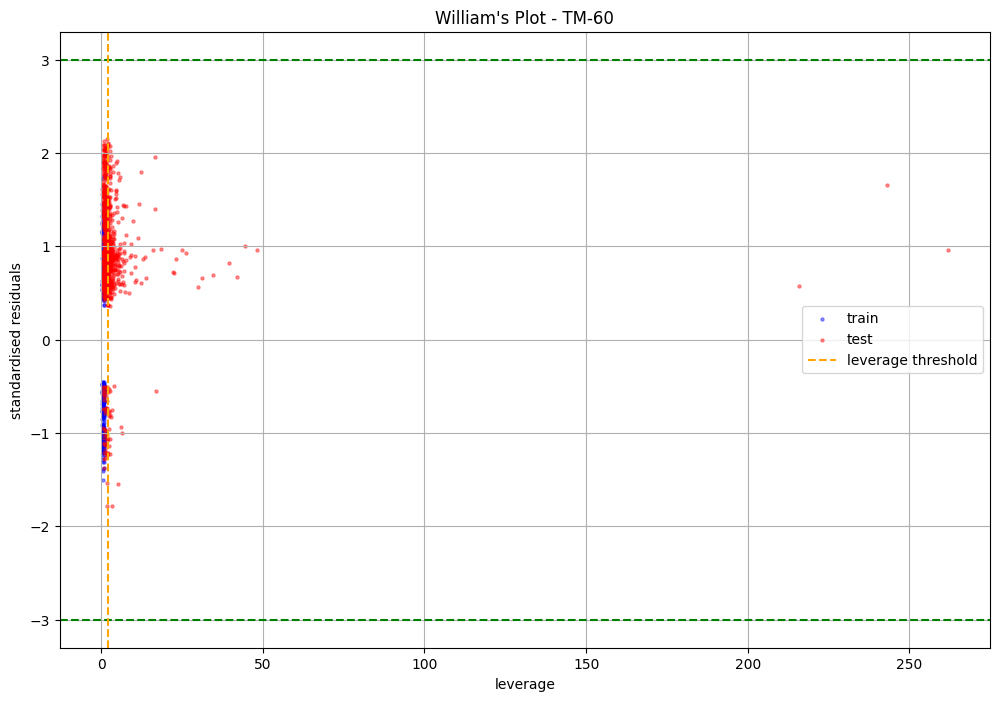

In [20]:
fig = plt.figure(figsize = (12,8))

plt.scatter(tr_leverages, tr_stand_resid, c='blue', label='train', s=5, alpha=0.4)
plt.scatter(te_leverages, te_stand_resid, c='red', label='test', s=5, alpha=0.4)

plt.axhline(3, color='green', linestyle='--')
plt.axhline(-3, color='green', linestyle='--')
plt.axvline(lev_thresh, color='orange', linestyle='--', label='leverage threshold')

# plt.xlim(0,10)
plt.xlabel('leverage')
plt.ylabel('standardised residuals')
plt.title("William's Plot - TM-60")

plt.legend()
plt.grid(True)
plt.show()

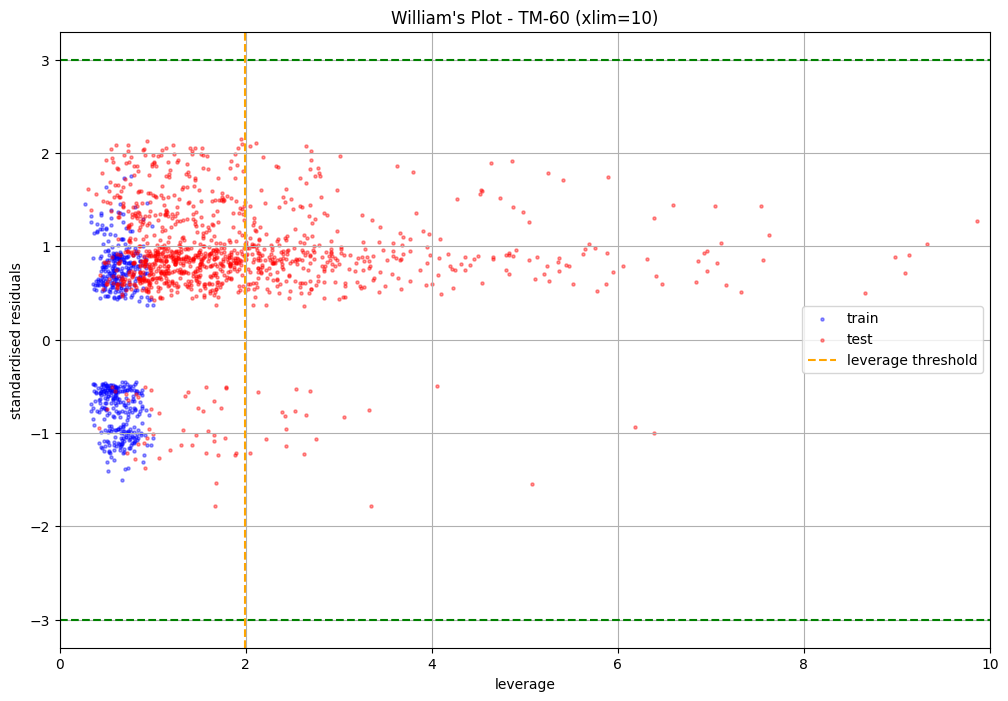

In [22]:
fig = plt.figure(figsize = (12,8))

plt.scatter(tr_leverages, tr_stand_resid, c='blue', label='train', s=5, alpha=0.4)
plt.scatter(te_leverages, te_stand_resid, c='red', label='test', s=5, alpha=0.4)

plt.axhline(3, color='green', linestyle='--')
plt.axhline(-3, color='green', linestyle='--')
plt.axvline(lev_thresh, color='orange', linestyle='--', label='leverage threshold')

plt.xlim(0,10) ##############
plt.xlabel('leverage')
plt.ylabel('standardised residuals')
plt.title("William's Plot - TM-60 (xlim=10)")

plt.legend()
plt.grid(True)
plt.show()

williams plots are usually used for regression models and so may not be totally applicable to classification models. take the above plots with a grain of salt